2. Time Series Analysis

2.1 Article counts of different universities over years


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

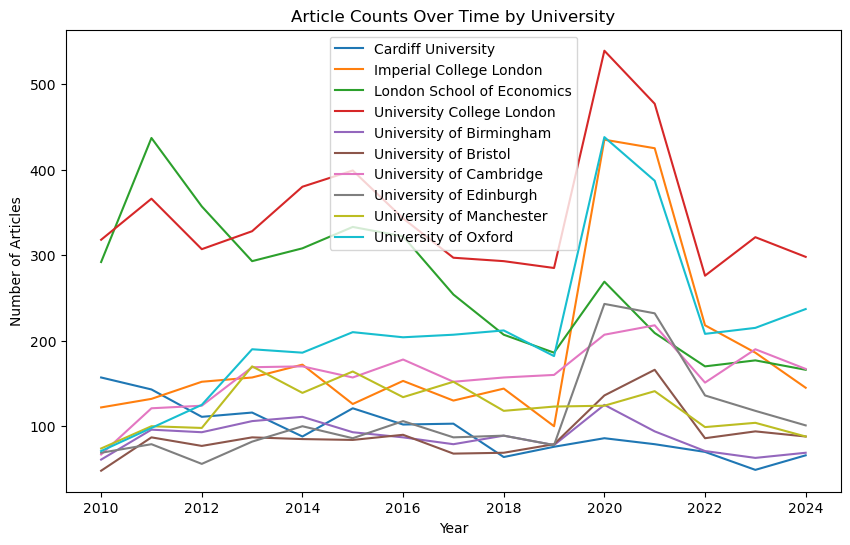

In [6]:
df = pd.read_csv('data/raw/combined_raw.csv')

df['webPublicationDate'] = pd.to_datetime(df['webPublicationDate'])
df['year'] = df['webPublicationDate'].dt.year

counts = df.groupby(['year', 'university']).size().reset_index(name='article_count')

plt.figure(figsize=(10, 6))

for uni in counts['university'].unique():
    subset = counts[counts['university'] == uni]
    plt.plot(subset['year'], subset['article_count'], label=uni)

plt.legend()
plt.title("Article Counts Over Time by University")
plt.xlabel("Year")
plt.ylabel("Number of Articles")

plt.show()

This line charts demonstrate the article counts of 10 universities and we can observe the changes and trends over time. 

The first observed pattern is a 'universal peak' of article counts around 2020, when most of the selected universities being mentioned in the media more frequently compared to other years. One major event happened at 2020 was the breakout of COVID-19, which influenced the majority of the population in the UK, as well as university students. Due to COVID-19, universities had to adjust their teaching mode, i.e. switching to online classes. Together with other associated adjustments, COVID-19 could be a reasonable explaination of this universal increase.

The second observation is that UCL has overall the largest article counts over these years. This is very reasonable, as UCL is one of the most famous universities in the UK, and its size is comparatively larger than the others in this chart, i.e. LSE, Oxford, and Imperial.

Third, we find that some universities displays different trends in terms of their article counts. For example, LSE shows a downward trend, and Imperial College shows an upward trend. 

In other times, the article counts of universities almost follow a similar trend. This implies the frequency of news and reports on universities is affected by larger scale social issues, like the COVID-19.

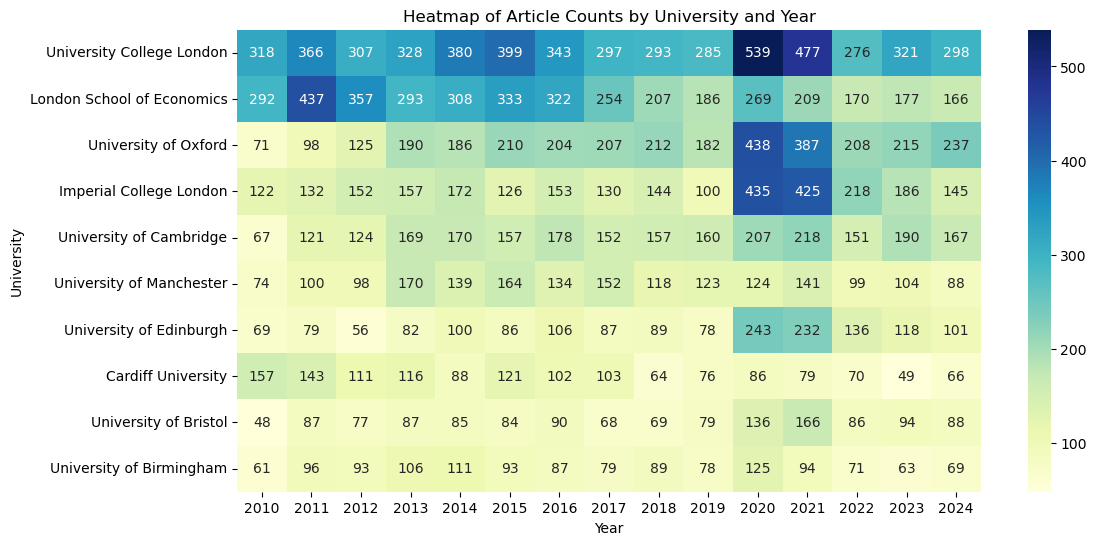

In [7]:
pivot = counts.pivot(
    index='university', 
    columns='year', 
    values='article_count'
).fillna(0)

pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot, 
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Heatmap of Article Counts by University and Year")
plt.xlabel("Year")
plt.ylabel("University")

plt.show()

This heatmap demonstrates the same information from the line chart, but tells more explicitly about the relative amount of articles related to different universities in different years. From this chart we can see that there are more articles related to universities in year 2020 and 2021; and over this 15-year time interval, the top 5 UK universities ('top' in terms of general reputation) have more media coverage than others.

2.2 Overlay the major events on the time series as vertical dashed lines